# Brain Tumor MRI — File 1 (MobileNetV2, MobileNetV3Large, DenseNet121, InceptionV3)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================
# (Optional) Install deps (Colab)
# =========================
# If Colab already has TensorFlow installed and you don't want to upgrade, you can skip.
# !pip -q install --upgrade tensorflow tensorflow-io

# Optional (only needed for model visualization parts)
# !pip -q install visualkeras pydot

# Optional (plot_model may need graphviz system package)
# !apt-get -qq install graphviz


In [ ]:
# =========================
# Imports
# =========================
import os
import random
import time
import gc

import numpy as np
import pandas as pd
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img

# plot_model (keep same name)
try:
    from tensorflow.keras.utils import plot_model
except Exception:
    from keras.utils import plot_model  # fallback

from IPython.display import display, Image

# Sklearn (for extra graphs)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)


In [ ]:
# =========================
# Global variables
# =========================
SAVE = False
SEED = 111

# Reproducibility
tf.keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Optional: stronger determinism (if supported)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# Visualization settings
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = (16, 10)
plt.rcParams.update({'font.size': 14})

# Data Classifications
CLASS_TYPES = ['pituitary', 'notumor', 'meningioma', 'glioma']
N_TYPES = len(CLASS_TYPES)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# =========================
# Speed / quality tuning (reduce training time)
# =========================
# Set FAST_MODE=True to train the three transfer-learning models faster on Colab.
# You can switch FAST_MODE=False for higher accuracy (more epochs / heavier augmentation).

FAST_MODE = True

# Mixed precision can significantly speed up training on most Colab GPUs (T4/L4/A100).
USE_MIXED_PRECISION = True

# Input resolution (smaller = faster). 128 is usually a good speed/quality trade-off.
IMAGE_SIZE_FAST = (128, 128)
IMAGE_SIZE_FULL = (150, 150)

# Batch size (bigger = fewer steps/epoch, faster if VRAM allows).
# If you hit OOM on any model, drop BATCH_SIZE_FAST to 32.
BATCH_SIZE_FAST = 64
BATCH_SIZE_FULL = 32

# Data augmentation level (heavy augmentation slows training a lot with ImageDataGenerator).
AUGMENTATION_MODE = 'light' if FAST_MODE else 'full'   # 'light' | 'medium' | 'full'

# Transfer learning training schedule
EPOCHS_HEAD = 4 if FAST_MODE else 12
EPOCHS_FINE = 2 if FAST_MODE else 8
FINE_TUNE = True
FINE_TUNE_FRACTION = 0.10 if FAST_MODE else 0.20

# Learning rates
LR_HEAD = 3e-4 if FAST_MODE else 1e-3
LR_FINE = 1e-4

# Label smoothing can improve generalization with fewer epochs
LABEL_SMOOTHING = 0.05 if FAST_MODE else 0.0

# Early stopping & ReduceLROnPlateau tuning
EARLY_STOP_PATIENCE = 2 if FAST_MODE else 5
REDUCE_LR_PATIENCE = 1 if FAST_MODE else 3

PLOT_EXTRA_GRAPHS = True  # set False to skip ROC/PR curves for faster evaluation

# Apply mixed precision (if enabled)
if USE_MIXED_PRECISION:
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision policy:', mixed_precision.global_policy())
    except Exception as e:
        print('Mixed precision not enabled:', e)

# Final chosen image_size / batch_size
image_size = IMAGE_SIZE_FAST if FAST_MODE else IMAGE_SIZE_FULL
batch_size = BATCH_SIZE_FAST if FAST_MODE else BATCH_SIZE_FULL

print('FAST_MODE:', FAST_MODE)
print('image_size:', image_size)
print('batch_size:', batch_size)
print('AUGMENTATION_MODE:', AUGMENTATION_MODE)


Mixed precision policy: <DTypePolicy "mixed_float16">
FAST_MODE: True
image_size: (128, 128)
batch_size: 64
AUGMENTATION_MODE: light


In [ ]:
# # =========================
# # Upload + Unzip Dataset (Colab)
# # =========================
# # Expected zip structure:
# #   Training/<class_name>/*.jpg
# #   Testing/<class_name>/*.jpg

# ZIP_NAME = "Dataset.zip"
# DATA_ROOT = "/content/drive/MyDrive/Anik_MSC/Dataset"   # extracted folder

# # Option A: If Dataset.zip already exists in your Colab session, it will unzip automatically.
# # Option B: Upload Dataset.zip using the next lines (uncomment):
# # from google.colab import files
# # uploaded = files.upload()  # select Dataset.zip

# if not os.path.exists(ZIP_NAME):
#     print(f"'{ZIP_NAME}' not found in /content. If you're on Colab, upload it first (files.upload()).")
# else:
#     if not os.path.isdir(os.path.join(DATA_ROOT, "Training")):
#         !unzip -q "{ZIP_NAME}" -d "{DATA_ROOT}"
#         print("Unzipped to:", DATA_ROOT)
#     else:
#         print("Dataset already extracted:", DATA_ROOT)

# print("DATA_ROOT contents:", os.listdir(DATA_ROOT) if os.path.isdir(DATA_ROOT) else "DATA_ROOT not found")


In [ ]:
# =========================
# Dataset Paths
# =========================
# Set USER_PATH to your extracted dataset folder.
# If you used the unzip cell above, USER_PATH should be DATA_ROOT.
DATA_ROOT = "/content/drive/MyDrive/Anik_MSC/Dataset"   # extracted folder
USER_PATH = DATA_ROOT  # <-- Change if your dataset is elsewhere

train_dir = USER_PATH + r'/Training/'
test_dir  = USER_PATH + r'/Testing/'

print("USER_PATH:", USER_PATH)
print("train_dir:", train_dir)
print("test_dir :", test_dir)

# Helpful checks (clear errors if path is wrong)
assert os.path.isdir(train_dir), f"Training folder not found: {train_dir}"
assert os.path.isdir(test_dir),  f"Testing folder not found: {test_dir}"


USER_PATH: /content/drive/MyDrive/Anik_MSC/Dataset
train_dir: /content/drive/MyDrive/Anik_MSC/Dataset/Training/
test_dir : /content/drive/MyDrive/Anik_MSC/Dataset/Testing/


In [ ]:
# =========================
# Function for importing data
# =========================
def get_data_labels(directory, shuffle=True, random_state=0):
    """
    Function used for going into the main training directory
    whose directory has sub-class-types.
    """
    from sklearn.utils import shuffle as sk_shuffle
    import os

    data_path = []
    data_labels = []

    for label in os.listdir(directory):
        label_dir = os.path.join(directory, label)

        # Avoid stray files (e.g., .DS_Store)
        if not os.path.isdir(label_dir):
            continue

        for image in os.listdir(label_dir):
            image_path = os.path.join(label_dir, image)
            data_path.append(image_path)
            data_labels.append(label)

    if shuffle:
        data_path, data_labels = sk_shuffle(data_path, data_labels, random_state=random_state)

    return data_path, data_labels


In [ ]:
# =========================
# Getting data using above function
# =========================
train_paths, train_labels = get_data_labels(train_dir)
test_paths, test_labels   = get_data_labels(test_dir)

print('Training')
print(f'Number of Paths: {len(train_paths)}')
print(f'Number of Labels: {len(train_labels)}')
print('\nTesting')
print(f'Number of Paths: {len(test_paths)}')
print(f'Number of Labels: {len(test_labels)}')


Training
Number of Paths: 5600
Number of Labels: 5600

Testing
Number of Paths: 1600
Number of Labels: 1600


Training Counts
{'pituitary': 1400, 'notumor': 1400, 'meningioma': 1400, 'glioma': 1400}

Testing Counts
{'pituitary': 400, 'notumor': 400, 'meningioma': 400, 'glioma': 400}


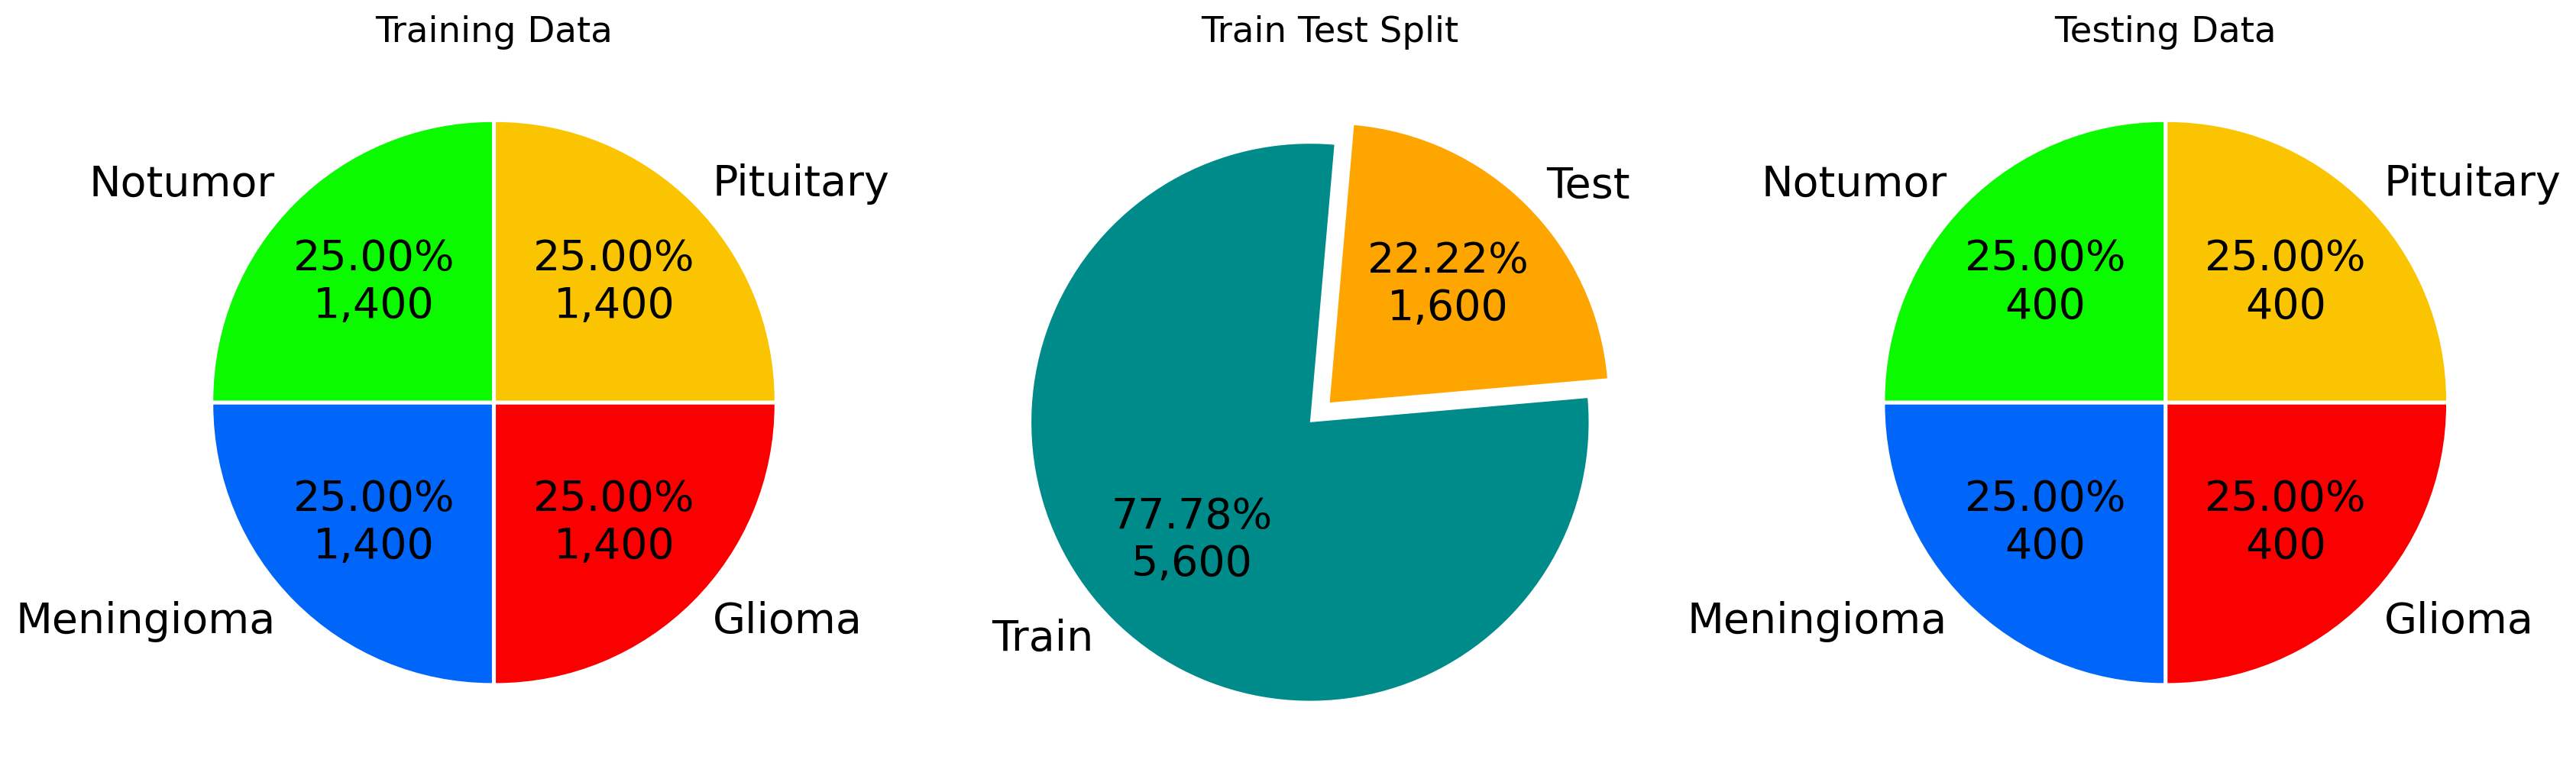

In [ ]:
# =========================
# Dataset distribution visualization
# =========================
_, ax = plt.subplots(ncols=3, figsize=(20, 14))

# Training type counts
class_counts_train = [len([x for x in train_labels if x == label]) for label in CLASS_TYPES]
print('Training Counts')
print(dict(zip(CLASS_TYPES, class_counts_train)))

ax[0].set_title('Training Data')
ax[0].pie(
    class_counts_train,
    labels=[label.title() for label in CLASS_TYPES],
    colors=['#FAC500', '#0BFA00', '#0066FA', '#FA0000'],
    autopct=lambda p: '{:.2f}%\n{:,.0f}'.format(p, p * sum(class_counts_train) / 100),
    explode=tuple(0.01 for _ in range(N_TYPES)),
    textprops={'fontsize': 20}
)

# Train/Test split
ax[1].set_title('Train Test Split')
ax[1].pie(
    [len(train_labels), len(test_labels)],
    labels=['Train', 'Test'],
    colors=['darkcyan', 'orange'],
    autopct=lambda p: '{:.2f}%\n{:,.0f}'.format(p, p * (len(train_labels) + len(test_labels)) / 100),
    explode=(0.1, 0),
    startangle=85,
    textprops={'fontsize': 20}
)

# Testing type counts
class_counts_test = [len([x for x in test_labels if x == label]) for label in CLASS_TYPES]
print('\nTesting Counts')
print(dict(zip(CLASS_TYPES, class_counts_test)))

ax[2].set_title('Testing Data')
ax[2].pie(
    class_counts_test,
    labels=[label.title() for label in CLASS_TYPES],
    colors=['#FAC500', '#0BFA00', '#0066FA', '#FA0000'],
    autopct=lambda p: '{:.2f}%\n{:,.0f}'.format(p, p * sum(class_counts_test) / 100),
    explode=tuple(0.01 for _ in range(N_TYPES)),
    textprops={'fontsize': 20}
)

plt.show()


x reshaped: (1, 150, 150, 3)


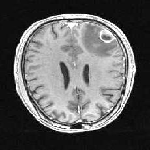

In [ ]:
# =========================
# Quick image sanity check
# =========================
im = load_img(train_paths[3], target_size=(150, 150))
im = img_to_array(im)

im = np.expand_dims(im, axis=0)
print(f'x reshaped: {im.shape}')

im /= np.max(im)  # normalization for display
im = array_to_img(im[0])
display(im)


In [ ]:
# =========================
# Function to display images by index
# =========================
def show_images(paths, label_paths, index_list=range(10), im_size=250, figsize=(12, 8), save=False):
    """
    Show images from a given path based on the inputted
    list indices related to the desired images one wishes
    to see.
    """
    num_images = len(list(index_list))
    num_rows = (num_images + 3) // 4

    _, ax = plt.subplots(nrows=num_rows, ncols=4, figsize=figsize)
    ax = ax.flatten()

    for i, index in enumerate(index_list):
        if i >= len(ax):
            break

        img = load_img(paths[index], target_size=(im_size, im_size))
        ax[i].imshow(img)
        ax[i].set_title(f'{index}: {label_paths[index]}')
        ax[i].axis('off')

    # Turn off unused axes (if any)
    for j in range(i + 1, len(ax)):
        ax[j].axis('off')

    plt.tight_layout()

    if save:
        plt.savefig('show_image.pdf')
    else:
        plt.show()


In [ ]:
# Four different data classification images, from different angles (images independent)
show_images(
    train_paths, train_labels,
    im_size=350, figsize=(13, 10),
    index_list=[0, 94, 235, 17,
                61, 324, 55, 45,
                374, 65, 391, 488]
)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# =========================
# Generator setup
# =========================
# NOTE:
# - image_size and batch_size are defined in the "Speed / quality tuning" cell above.
# - Heavy ImageDataGenerator augmentation can be a major bottleneck (slow CPU image ops).
#   So we use LIGHT augmentation by default in FAST_MODE.

if AUGMENTATION_MODE == 'light':
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=8,
        zoom_range=0.05,
        horizontal_flip=True,
        vertical_flip=False,
        fill_mode="nearest"
    )
elif AUGMENTATION_MODE == 'medium':
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        brightness_range=(0.9, 1.1),
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.10,
        horizontal_flip=True,
        vertical_flip=False,
        fill_mode="nearest"
    )
else:
    # Full / heavier augmentation (slower)
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        brightness_range=(0.85, 1.15),
        width_shift_range=0.02,
        height_shift_range=0.02,
        shear_range=8.0,
        zoom_range=0.10,
        horizontal_flip=True,
        vertical_flip=False,
        fill_mode="nearest"
    )

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    seed=SEED
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False,
    seed=SEED
)


Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
# =========================
# Class indices
# =========================
class_indices_train = train_generator.class_indices
class_indices_train_list = list(train_generator.class_indices.keys())

print("Categorical types for the training data:")
print(class_indices_train)


Categorical types for the training data:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
# =========================
# Visualize augmentation
# =========================
def show_ImageDataGenerator(ImageDataGenerator, num_samples=5, figsize=(12, 12), save=False):
    """
    Function to viusalize how the ImageDataGenerator augments the data
    """
    _ = ImageDataGenerator  # kept for signature compatibility

    # Pull one augmented batch
    batch_x, batch_y = next(train_generator)
    images = batch_x[:num_samples]

    fig, axes = plt.subplots(1, num_samples, figsize=figsize)
    if num_samples == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.axis('off')

    plt.tight_layout()

    if save:
        plt.savefig('show_ImageDataGenerator.pdf')

    plt.show()


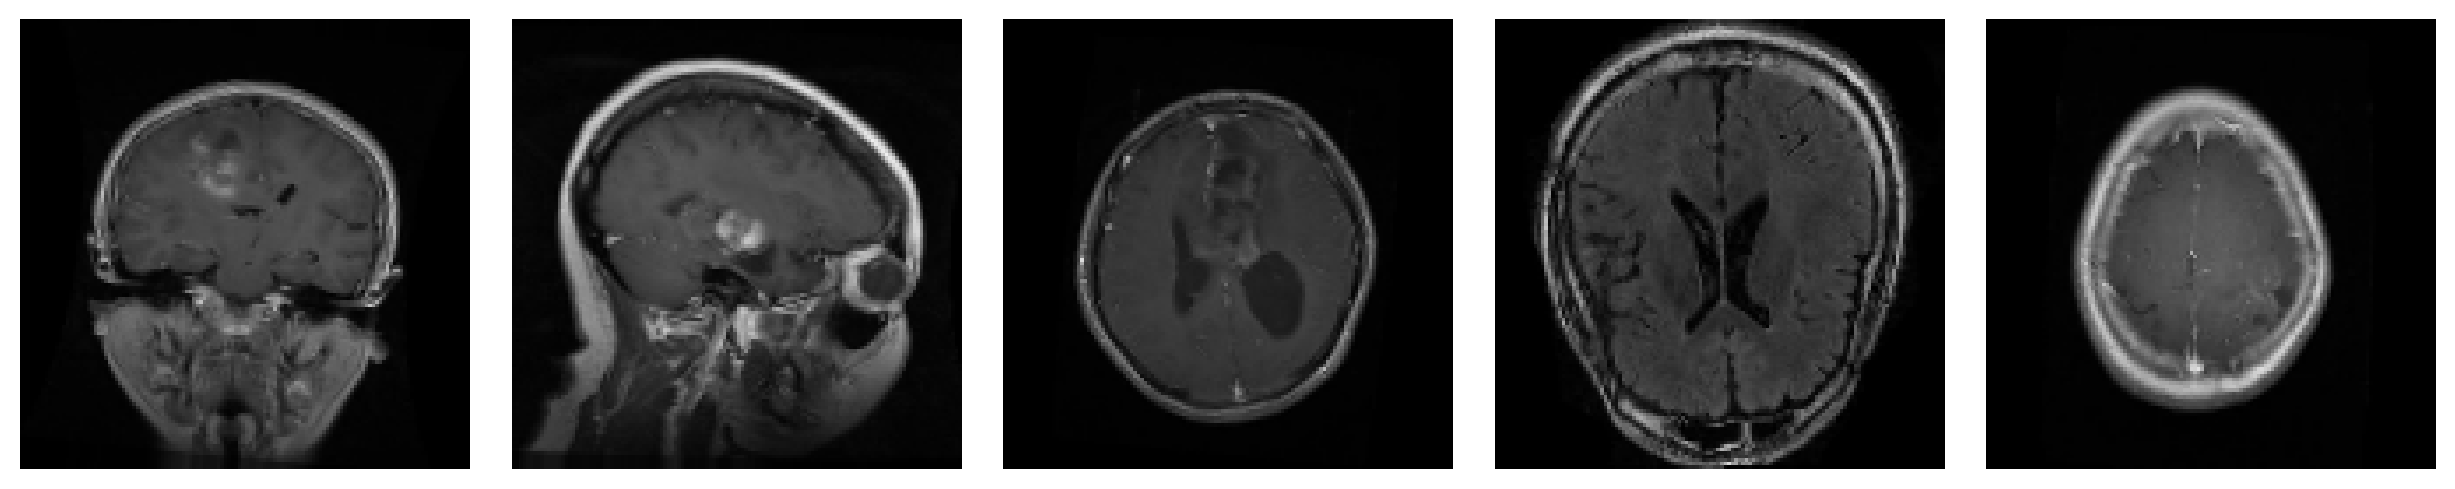

In [ ]:
show_ImageDataGenerator(train_datagen, num_samples=5, figsize=(12.5, 8), save=SAVE)

In [ ]:
# =========================
# Training configuration
# =========================
image_shape = (image_size[0], image_size[1], 3)

# EPOCHS_HEAD / EPOCHS_FINE are defined in the tuning cell.
# FINE_TUNE and FINE_TUNE_FRACTION are also defined there.

steps_per_epoch = max(1, train_generator.samples // batch_size)
validation_steps = max(1, test_generator.samples // batch_size)

print(f'Image shape: {image_shape}')
print(f'Batch size: {batch_size}')
print(f'Steps Per Epoch: {steps_per_epoch}')
print(f'Validation steps: {validation_steps}')

print('EPOCHS_HEAD:', EPOCHS_HEAD)
print('EPOCHS_FINE:', EPOCHS_FINE)
print('FINE_TUNE:', FINE_TUNE)
print('FINE_TUNE_FRACTION:', FINE_TUNE_FRACTION)
print('LR_HEAD:', LR_HEAD)
print('LR_FINE:', LR_FINE)


Image shape: (128, 128, 3)
Batch size: 64
Steps Per Epoch: 87
Validation steps: 25
EPOCHS_HEAD: 4
EPOCHS_FINE: 2
FINE_TUNE: True
FINE_TUNE_FRACTION: 0.1
LR_HEAD: 0.0003
LR_FINE: 0.0001


In [ ]:
# =========================
# Output Images and Labels Visualization
# =========================
def plot_sample_predictions(model, test_generator, categories, test_dir, num_samples=9, figsize=(12, 8)):
    """
    Nice display of prediction samples to see CNN predictions
    for classification.
    """
    _ = test_dir  # kept for signature compatibility

    # Ensure generator starts from beginning
    try:
        test_generator.reset()
    except Exception:
        pass

    predictions = model.predict(test_generator, verbose=0)
    predicted_categories = np.argmax(predictions, axis=1)
    true_categories = test_generator.classes

    test_images = np.array(test_generator.filepaths)
    sample_indices = np.random.choice(len(test_images), size=num_samples, replace=False)

    sample_images = test_images[sample_indices]
    sample_predictions = [categories[predicted_categories[i]] for i in sample_indices]
    sample_true_labels = [categories[true_categories[i]] for i in sample_indices]

    plt.figure(figsize=figsize)

    grid = int(np.ceil(np.sqrt(num_samples)))
    for i, image_path in enumerate(sample_images):
        plt.subplot(grid, grid, i + 1)
        img = plt.imread(image_path)
        plt.imshow(img)
        plt.axis("off")

        prediction_color = 'green' if sample_predictions[i] == sample_true_labels[i] else 'red'
        plt.title(f"Predicted: {sample_predictions[i]}\nTrue: {sample_true_labels[i]}", color=prediction_color)

    plt.tight_layout()
    plt.show()


# =========================
# Confusion matrix
# =========================
def CM(CNN_model, test_generator, categories):
    """
    Function to return the confusion matrix of a given CNN model.
    """
    _ = categories  # kept for signature compatibility
    from sklearn.metrics import confusion_matrix

    try:
        test_generator.reset()
    except Exception:
        pass

    predictions = CNN_model.predict(test_generator, verbose=0)
    predicted_categories = np.argmax(predictions, axis=1)
    true_categories = test_generator.classes

    confusion_matrix_array = confusion_matrix(true_categories, predicted_categories)
    return confusion_matrix_array


# =========================
# Metric Analysis
# =========================
def calculate_metrics(confusion_matrix, categories):
    """
    Function to calculate important metrics for multi-classification problems.
    """
    cm = confusion_matrix.astype(np.float64)

    # Prevent divide-by-zero warnings
    eps = 1e-12
    precision = np.diag(cm) / (np.sum(cm, axis=0) + eps)
    recall    = np.diag(cm) / (np.sum(cm, axis=1) + eps)
    f1_score  = 2 * (precision * recall) / (precision + recall + eps)
    accuracy  = np.sum(np.diag(cm)) / (np.sum(cm) + eps)

    for i, category in enumerate(categories):
        print(f"Class: {category.title()}")
        print(f"Precision: {precision[i]:.3f}")
        print(f"Recall: {recall[i]:.3f}")
        print(f"F1-Score: {f1_score[i]:.3f}\n")

    print(f"\nAccuracy: {accuracy:.3f}")


In [ ]:
# =========================
# Helper functions for the four selected models
# =========================
def compile_model(model, lr=1e-3):
    """Compile with categorical crossentropy + accuracy (Keras 3 compatible)."""
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
    return model

def get_callbacks(model_name):
    """Common callbacks (early stop + reduce LR + best checkpoint).
    Patience values are controlled by EARLY_STOP_PATIENCE / REDUCE_LR_PATIENCE in the tuning cell.
    """
    safe_name = model_name.replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "")
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=EARLY_STOP_PATIENCE,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=REDUCE_LR_PATIENCE,
            min_delta=1e-4,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f"{safe_name}_best.keras",
            monitor='val_accuracy',
            mode='max',
            save_best_only=True,
            verbose=1
        )
    ]

def merge_histories(history_head, history_fine=None):
    """Merge two Keras History objects into a single dict for plotting."""
    out = {}
    if history_head is None:
        return out
    for k, v in history_head.history.items():
        out[k] = list(v)

    if history_fine is not None:
        for k, v in history_fine.history.items():
            out[k] = out.get(k, []) + list(v)
    return out

def plot_training_curves(history_dict, model_title):
    """Plot accuracy/loss curves."""
    if not history_dict:
        print("No history to plot.")
        return

    fig, ax = plt.subplots(ncols=2, figsize=(15, 6))

    if 'accuracy' in history_dict and 'val_accuracy' in history_dict:
        ax[0].plot(history_dict['accuracy'])
        ax[0].plot(history_dict['val_accuracy'])
        ax[0].set_title(f'{model_title} — Accuracy')
        ax[0].set_xlabel('Epoch')
        ax[0].set_ylabel('Accuracy')
        ax[0].legend(['Train', 'Validation'])
        ax[0].grid(alpha=0.2)

    if 'loss' in history_dict and 'val_loss' in history_dict:
        ax[1].plot(history_dict['loss'])
        ax[1].plot(history_dict['val_loss'])
        ax[1].set_title(f'{model_title} — Loss')
        ax[1].set_xlabel('Epoch')
        ax[1].set_ylabel('Loss')
        ax[1].legend(['Train', 'Validation'])
        ax[1].grid(alpha=0.2)

    plt.show()

def get_predictions(model, generator):
    """Get y_true, y_pred, y_prob for a generator (assumes shuffle=False for test generator)."""
    try:
        generator.reset()
    except Exception:
        pass

    y_prob = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes
    return y_true, y_pred, y_prob

def plot_confusion_matrices(y_true, y_pred, class_names, model_title):
    """Plot raw and normalized confusion matrices."""
    cm = confusion_matrix(y_true, y_pred)

    # Raw
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=[c.title() for c in class_names],
                yticklabels=[c.title() for c in class_names])
    plt.title(f"{model_title} — Confusion Matrix (Counts)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Normalized
    cmn = cm.astype(np.float64) / np.maximum(cm.sum(axis=1, keepdims=True), 1e-12)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=[c.title() for c in class_names],
                yticklabels=[c.title() for c in class_names])
    plt.title(f"{model_title} — Confusion Matrix (Normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return cm

def plot_classification_report_heatmap(y_true, y_pred, class_names, model_title):
    """Print and plot classification report."""
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    df = pd.DataFrame(report).transpose()
    display(df)

    # heatmap for per-class rows only
    per_class = df.iloc[:len(class_names)][['precision', 'recall', 'f1-score']]
    plt.figure(figsize=(8, 4))
    sns.heatmap(per_class, annot=True, fmt=".3f", cmap="viridis", cbar=True)
    plt.title(f"{model_title} — Classification Report (per class)")
    plt.show()

def plot_roc_curves(y_true, y_prob, class_names, model_title):
    """One-vs-rest ROC curves for multiclass."""
    y_true_oh = tf.keras.utils.to_categorical(y_true, num_classes=len(class_names))

    plt.figure(figsize=(9, 7))
    for i, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_oh[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

    # Micro-average
    fpr_micro, tpr_micro, _ = roc_curve(y_true_oh.ravel(), y_prob.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, linestyle='--', label=f"micro-average (AUC={auc_micro:.3f})")

    plt.plot([0, 1], [0, 1], linestyle=':')
    plt.title(f"{model_title} — ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

def plot_precision_recall_curves(y_true, y_prob, class_names, model_title):
    """One-vs-rest Precision-Recall curves for multiclass."""
    y_true_oh = tf.keras.utils.to_categorical(y_true, num_classes=len(class_names))

    plt.figure(figsize=(9, 7))
    for i, name in enumerate(class_names):
        precision, recall, _ = precision_recall_curve(y_true_oh[:, i], y_prob[:, i])
        ap = average_precision_score(y_true_oh[:, i], y_prob[:, i])
        plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

    ap_micro = average_precision_score(y_true_oh, y_prob, average='micro')
    plt.title(f"{model_title} — Precision-Recall Curves (micro-AP={ap_micro:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

def fine_tune_base_model(model, base_model, fine_tune_fraction=0.2, lr=1e-4):
    """Unfreeze last fraction of layers for fine-tuning.
    Also keeps BatchNorm layers frozen for stability (recommended).
    """
    if base_model is None:
        return None

    base_model.trainable = True
    fine_tune_at = int(len(base_model.layers) * (1 - fine_tune_fraction))

    # Freeze early layers
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    # Keep BatchNorm frozen in the unfrozen part too (stability + often faster)
    for layer in base_model.layers[fine_tune_at:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    compile_model(model, lr=lr)
    print(f"Fine-tuning from layer {fine_tune_at} / {len(base_model.layers)} (unfroze last {fine_tune_fraction:.0%})")
    return fine_tune_at

# Collect results here
results = {}


In [ ]:
# =========================
# Model builders
# Each builder returns: (model, base_model_or_None)
# =========================
def build_mobilenetv2_model(input_shape, n_classes):
    preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
    base = tf.keras.applications.MobileNetV2(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    # generator yields [0,1] (rescale=1/255). Most preprocess_input expect [0,255].
    x = tf.keras.layers.Lambda(lambda t: preprocess(t * 255.0), name="mobilenetv2_preprocess")(inputs)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.30, seed=SEED)(x)
    outputs = tf.keras.layers.Dense(n_classes, activation='softmax', dtype='float32')(x)
    model = tf.keras.Model(inputs, outputs, name="MobileNetV2")
    return model, base


def build_mobilenetv3large_model(input_shape, n_classes):
    preprocess = tf.keras.applications.mobilenet_v3.preprocess_input
    base = tf.keras.applications.MobileNetV3Large(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    # generator yields [0,1] (rescale=1/255). preprocess_input is kept for consistency.
    x = tf.keras.layers.Lambda(lambda t: preprocess(t * 255.0), name="mobilenetv3large_preprocess")(inputs)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.30, seed=SEED)(x)
    outputs = tf.keras.layers.Dense(n_classes, activation='softmax', dtype='float32')(x)
    model = tf.keras.Model(inputs, outputs, name="MobileNetV3Large")
    return model, base


def build_densenet121_model(input_shape, n_classes):
    preprocess = tf.keras.applications.densenet.preprocess_input
    base = tf.keras.applications.DenseNet121(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    # generator yields [0,1] (rescale=1/255). Most preprocess_input expect [0,255].
    x = tf.keras.layers.Lambda(lambda t: preprocess(t * 255.0), name="densenet121_preprocess")(inputs)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.30, seed=SEED)(x)
    outputs = tf.keras.layers.Dense(n_classes, activation='softmax', dtype='float32')(x)
    model = tf.keras.Model(inputs, outputs, name="DenseNet121")
    return model, base


def build_inceptionv3_model(input_shape, n_classes):
    preprocess = tf.keras.applications.inception_v3.preprocess_input
    base = tf.keras.applications.InceptionV3(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    # generator yields [0,1] (rescale=1/255). Most preprocess_input expect [0,255].
    x = tf.keras.layers.Lambda(lambda t: preprocess(t * 255.0), name="inceptionv3_preprocess")(inputs)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.30, seed=SEED)(x)
    outputs = tf.keras.layers.Dense(n_classes, activation='softmax', dtype='float32')(x)
    model = tf.keras.Model(inputs, outputs, name="InceptionV3")
    return model, base


def fine_tune_base_model(model, base_model, fine_tune_fraction=0.15, lr=1e-5):
    """Unfreeze the last fraction of the base model, keep BN frozen, and recompile."""
    base_model.trainable = True

    total_layers = len(base_model.layers)
    start_idx = int(total_layers * (1.0 - fine_tune_fraction))

    for i, layer in enumerate(base_model.layers):
        if i < start_idx:
            layer.trainable = False
        else:
            # Keep BatchNorm frozen for stability
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False
            else:
                layer.trainable = True

    compile_model(model, lr=lr)
    return model


In [ ]:
# =========================
# Misclassified images
# =========================
def visualize_misclassified_images(model, test_generator, class_indices):
    """
    Visualize misclassified images from the test set alongside their predicted and true labels.
    """
    from tensorflow.keras.preprocessing.image import array_to_img

    # ensure stable iteration
    try:
        test_generator.reset()
    except Exception:
        pass

    misclassified_images = []
    misclassified_labels_true = []
    misclassified_labels_pred = []

    # Use index-based access to avoid exhausting the generator unpredictably
    for i in range(len(test_generator)):
        batch_images, batch_labels = test_generator[i]
        batch_predictions = model.predict(batch_images, verbose=0)

        predicted_labels = [list(class_indices.keys())[np.argmax(pred)] for pred in batch_predictions]
        true_labels = [list(class_indices.keys())[np.argmax(lab)] for lab in batch_labels]

        for j in range(len(batch_images)):
            if predicted_labels[j] != true_labels[j]:
                misclassified_images.append(batch_images[j])
                misclassified_labels_true.append(true_labels[j])
                misclassified_labels_pred.append(predicted_labels[j])

    num_misclassified = len(misclassified_images)
    print("Misclassified images found:", num_misclassified)

    if num_misclassified == 0:
        print("No misclassifications to display.")
        return

    # Show at most 24 misclassified images to keep the plot readable
    max_show = min(24, num_misclassified)
    num_rows = int(np.ceil(max_show / 4))
    plt.figure(figsize=(12, 3 * num_rows))

    for k in range(max_show):
        plt.subplot(num_rows, 4, k + 1)
        plt.title(
            f"True: {misclassified_labels_true[k]}\nPred: {misclassified_labels_pred[k]}",
            color='red'
        )
        plt.imshow(array_to_img(misclassified_images[k]))
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # reset again for safety
    try:
        test_generator.reset()
    except Exception:
        pass


In [ ]:
# =========================
# Evaluate + plot wrapper (used by every model)
# =========================
def evaluate_and_plot(model, history_dict, model_title):
    # Curves
    plot_training_curves(history_dict, model_title)

    # Evaluation
    try:
        test_generator.reset()
    except Exception:
        pass

    loss, acc = model.evaluate(test_generator, verbose=0)
    print(f"{model_title} — Test Loss: {loss:.5f}")
    print(f"{model_title} — Test Accuracy: {acc:.5f}")

    # Predictions for graphs
    y_true, y_pred, y_prob = get_predictions(model, test_generator)

    # Confusion matrix (counts + normalized)
    cm = plot_confusion_matrices(y_true, y_pred, class_indices_train_list, model_title)

    # Printed metrics (your baseline function)
    calculate_metrics(cm, categories=class_indices_train_list)

    # Classification report (extra)
    plot_classification_report_heatmap(y_true, y_pred, class_indices_train_list, model_title)

    # ROC + PR curves (optional extra)
    if 'PLOT_EXTRA_GRAPHS' in globals() and PLOT_EXTRA_GRAPHS:
        plot_roc_curves(y_true, y_prob, class_indices_train_list, model_title)
        plot_precision_recall_curves(y_true, y_prob, class_indices_train_list, model_title)

    # Sample predictions & misclassified images (baseline functions)
    plot_sample_predictions(
        model=model,
        test_generator=test_generator,
        categories=class_indices_train_list,
        test_dir=test_dir,
        num_samples=9,
        figsize=(13, 12)
    )

    visualize_misclassified_images(model, test_generator, test_generator.class_indices)

    return {"loss": float(loss), "accuracy": float(acc)}


## Model 1: MobileNetV2

In [ ]:
# =========================
# Build + compile — MobileNetV2
# =========================
tf.keras.backend.clear_session()
gc.collect()

MODEL_NAME_1 = "MobileNetV2"

model_1, base_1 = build_mobilenetv2_model(image_shape, N_TYPES)
compile_model(model_1, lr=LR_HEAD)
model_1.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocess (Lambda) │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# =========================
# Train — MobileNetV2
# =========================
callbacks_1 = get_callbacks(MODEL_NAME_1)

# Reset generators before training (good practice)
try:
    train_generator.reset()
    test_generator.reset()
except Exception:
    pass

t0 = time.time()
history_1_head = model_1.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_HEAD,
    validation_data=test_generator,
    validation_steps=validation_steps,
    callbacks=callbacks_1
)
t1 = time.time()
print(f"MobileNetV2 head training time: {(t1 - t0)/60:.2f} min")

history_1_fine = None
if FINE_TUNE and base_1 is not None:
    # Fine-tune the last fraction of the backbone
    fine_tune_base_model(model_1, base_1, fine_tune_fraction=FINE_TUNE_FRACTION, lr=LR_FINE)

    t2 = time.time()
    history_1_fine = model_1.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS_FINE,
        validation_data=test_generator,
        validation_steps=validation_steps,
        callbacks=callbacks_1
    )
    t3 = time.time()
    print(f"MobileNetV2 fine-tuning time: {(t3 - t2)/60:.2f} min")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/4
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.4132 - loss: 1.4554 
Epoch 1: val_accuracy improved from -inf to 0.68687, saving model to MobileNetV2_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 2002s 23s/step - accuracy: 0.4145 - loss: 1.4525 - val_accuracy: 0.6869 - val_loss: 0.8816 - learning_rate: 3.0000e-04
Epoch 2/4
 1/87 ━━━━━━━━━━━━━━━━━━━━ 1:15 875ms/step - accuracy: 0.7656 - loss: 0.8121

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.68687 to 0.68813, saving model to MobileNetV2_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.7656 - loss: 0.8121 - val_accuracy: 0.6881 - val_loss: 0.8807 - learning_rate: 3.0000e-04
Epoch 3/4
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - accuracy: 0.7288 - loss: 0.8014
Epoch 3: val_accuracy improved from 0.68813 to 0.74125, saving model to MobileNetV2_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 76s 875ms/step - accuracy: 0.7290 - loss: 0.8011 - val_accuracy: 0.7412 - val_loss: 0.7966 - learning_rate: 3.0000e-04
Epoch 4/4
 1/87 ━━━━━━━━━━━━━━━━━━━━ 49s 573ms/step - accuracy: 0.6875 - loss: 0.9876
Epoch 4: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 4: val_accuracy improved from 0.74125 to 0.74313, saving model to MobileNetV2_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 0.6875 - loss: 0.9876 - val_accuracy: 0.7431 - val_loss: 0.7989 - learning_rate: 3.0000e-04
Restoring model weights from 

In [ ]:
# =========================
# Evaluate + graphs — MobileNetV2
# =========================
history_1 = merge_histories(history_1_head, history_1_fine)

metrics_1 = evaluate_and_plot(model_1, history_1, MODEL_NAME_1)
results[MODEL_NAME_1] = metrics_1


Output hidden; open in https://colab.research.google.com to view.

## Model 2: MobileNetV3Large

In [ ]:
# =========================
# Build + compile — MobileNetV3Large
# =========================
tf.keras.backend.clear_session()
gc.collect()

MODEL_NAME_2 = "MobileNetV3Large"

model_2, base_2 = build_mobilenetv3large_model(image_shape, N_TYPES)
compile_model(model_2, lr=LR_HEAD)
model_2.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:517: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV3Large"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv3large_preprocess     │ (None, 128, 128, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 4, 4, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         3,844 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,196 (11.44 MB)

 Trainable params: 3,844 (15.02 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [ ]:
# =========================
# Train — MobileNetV3Large
# =========================
callbacks_2 = get_callbacks(MODEL_NAME_2)

# Reset generators before training (good practice)
try:
    train_generator.reset()
    test_generator.reset()
except Exception:
    pass

t0 = time.time()
history_2_head = model_2.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_HEAD,
    validation_data=test_generator,
    validation_steps=validation_steps,
    callbacks=callbacks_2
)
t1 = time.time()
print(f"MobileNetV3Large head training time: {(t1 - t0)/60:.2f} min")

history_2_fine = None
if FINE_TUNE and base_2 is not None:
    # Fine-tune the last fraction of the backbone
    fine_tune_base_model(model_2, base_2, fine_tune_fraction=FINE_TUNE_FRACTION, lr=LR_FINE)

    t2 = time.time()
    history_2_fine = model_2.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS_FINE,
        validation_data=test_generator,
        validation_steps=validation_steps,
        callbacks=callbacks_2
    )
    t3 = time.time()
    print(f"MobileNetV3Large fine-tuning time: {(t3 - t2)/60:.2f} min")


Epoch 1/4
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.2557 - loss: 2.1958
Epoch 1: val_accuracy improved from -inf to 0.61125, saving model to MobileNetV3Large_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 69s 719ms/step - accuracy: 0.2568 - loss: 2.1902 - val_accuracy: 0.6112 - val_loss: 1.0202 - learning_rate: 3.0000e-04
Epoch 2/4
 1/87 ━━━━━━━━━━━━━━━━━━━━ 47s 549ms/step - accuracy: 0.4688 - loss: 1.2031

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.61125 to 0.61250, saving model to MobileNetV3Large_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.4688 - loss: 1.2031 - val_accuracy: 0.6125 - val_loss: 1.0162 - learning_rate: 3.0000e-04
Epoch 3/4
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.5935 - loss: 1.0558
Epoch 3: val_accuracy improved from 0.61250 to 0.71562, saving model to MobileNetV3Large_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 60s 690ms/step - accuracy: 0.5939 - loss: 1.0550 - val_accuracy: 0.7156 - val_loss: 0.8371 - learning_rate: 3.0000e-04
Epoch 4/4
 1/87 ━━━━━━━━━━━━━━━━━━━━ 48s 561ms/step - accuracy: 0.7188 - loss: 0.8676
Epoch 4: val_accuracy did not improve from 0.71562
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.7188 - loss: 0.8676 - val_accuracy: 0.7156 - val_loss: 0.8365 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 4.
MobileNetV3Large head training time: 2.45 min
Epoch 1/2
87/87 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
# =========================
# Evaluate + graphs — MobileNetV3Large
# =========================
history_2 = merge_histories(history_2_head, history_2_fine)

metrics_2 = evaluate_and_plot(model_2, history_2, MODEL_NAME_2)
results[MODEL_NAME_2] = metrics_2


Output hidden; open in https://colab.research.google.com to view.

## Model 3: DenseNet121

In [ ]:
# =========================
# Build + compile — DenseNet121
# =========================
tf.keras.backend.clear_session()
gc.collect()

MODEL_NAME_3 = "DenseNet121"

model_3, base_3 = build_densenet121_model(image_shape, N_TYPES)
compile_model(model_3, lr=LR_HEAD)
model_3.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121_preprocess (Lambda) │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041,604 (26.86 MB)

 Trainable params: 4,100 (16.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
# =========================
# Train — DenseNet121
# =========================
callbacks_3 = get_callbacks(MODEL_NAME_3)

# Reset generators before training (good practice)
try:
    train_generator.reset()
    test_generator.reset()
except Exception:
    pass

t0 = time.time()
history_3_head = model_3.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_HEAD,
    validation_data=test_generator,
    validation_steps=validation_steps,
    callbacks=callbacks_3
)
t1 = time.time()
print(f"DenseNet121 head training time: {(t1 - t0)/60:.2f} min")

history_3_fine = None
if FINE_TUNE and base_3 is not None:
    # Fine-tune the last fraction of the backbone
    fine_tune_base_model(model_3, base_3, fine_tune_fraction=FINE_TUNE_FRACTION, lr=LR_FINE)

    t2 = time.time()
    history_3_fine = model_3.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS_FINE,
        validation_data=test_generator,
        validation_steps=validation_steps,
        callbacks=callbacks_3
    )
    t3 = time.time()
    print(f"DenseNet121 fine-tuning time: {(t3 - t2)/60:.2f} min")


Epoch 1/4
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.3388 - loss: 2.1849
Epoch 1: val_accuracy improved from -inf to 0.63687, saving model to DenseNet121_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 89s 868ms/step - accuracy: 0.3397 - loss: 2.1809 - val_accuracy: 0.6369 - val_loss: 1.0823 - learning_rate: 3.0000e-04
Epoch 2/4
 1/87 ━━━━━━━━━━━━━━━━━━━━ 1:14 865ms/step - accuracy: 0.5938 - loss: 1.3557

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.63687 to 0.63875, saving model to DenseNet121_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.5938 - loss: 1.3557 - val_accuracy: 0.6388 - val_loss: 1.0803 - learning_rate: 3.0000e-04
Epoch 3/4
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.5574 - loss: 1.3135
Epoch 3: val_accuracy improved from 0.63875 to 0.70750, saving model to DenseNet121_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 69s 791ms/step - accuracy: 0.5578 - loss: 1.3124 - val_accuracy: 0.7075 - val_loss: 0.9128 - learning_rate: 3.0000e-04
Epoch 4/4
 1/87 ━━━━━━━━━━━━━━━━━━━━ 29s 340ms/step - accuracy: 0.3438 - loss: 1.9064
Epoch 4: val_accuracy improved from 0.70750 to 0.70875, saving model to DenseNet121_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.3438 - loss: 1.9064 - val_accuracy: 0.7088 - val_loss: 0.9047 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 4.
DenseNet121 head training time: 3.03 min
Epoch

In [ ]:
# =========================
# Evaluate + graphs — DenseNet121
# =========================
history_3 = merge_histories(history_3_head, history_3_fine)

metrics_3 = evaluate_and_plot(model_3, history_3, MODEL_NAME_3)
results[MODEL_NAME_3] = metrics_3


Output hidden; open in https://colab.research.google.com to view.

## Model 4: InceptionV3

In [ ]:
# =========================
# Build + compile — InceptionV3
# =========================
tf.keras.backend.clear_session()
gc.collect()

MODEL_NAME_4 = "InceptionV3"

model_4, base_4 = build_inceptionv3_model(image_shape, N_TYPES)
compile_model(model_4, lr=LR_HEAD)
model_4.summary()


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "InceptionV3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inceptionv3_preprocess (Lambda) │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 2, 2, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,810,980 (83.20 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
# =========================
# Train — InceptionV3
# =========================
callbacks_4 = get_callbacks(MODEL_NAME_4)

# Reset generators before training (good practice)
try:
    train_generator.reset()
    test_generator.reset()
except Exception:
    pass

t0 = time.time()
history_4_head = model_4.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_HEAD,
    validation_data=test_generator,
    validation_steps=validation_steps,
    callbacks=callbacks_4
)
t1 = time.time()
print(f"InceptionV3 head training time: {(t1 - t0)/60:.2f} min")

history_4_fine = None
if FINE_TUNE and base_4 is not None:
    # Fine-tune the last fraction of the backbone
    fine_tune_base_model(model_4, base_4, fine_tune_fraction=FINE_TUNE_FRACTION, lr=LR_FINE)

    t2 = time.time()
    history_4_fine = model_4.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS_FINE,
        validation_data=test_generator,
        validation_steps=validation_steps,
        callbacks=callbacks_4
    )
    t3 = time.time()
    print(f"InceptionV3 fine-tuning time: {(t3 - t2)/60:.2f} min")


Epoch 1/4
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.3797 - loss: 2.0754
Epoch 1: val_accuracy improved from -inf to 0.69000, saving model to InceptionV3_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 80s 814ms/step - accuracy: 0.3810 - loss: 2.0704 - val_accuracy: 0.6900 - val_loss: 1.0276 - learning_rate: 3.0000e-04
Epoch 2/4
 1/87 ━━━━━━━━━━━━━━━━━━━━ 52s 613ms/step - accuracy: 0.6094 - loss: 1.3399

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.69000 to 0.69187, saving model to InceptionV3_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step - accuracy: 0.6094 - loss: 1.3399 - val_accuracy: 0.6919 - val_loss: 1.0176 - learning_rate: 3.0000e-04
Epoch 3/4
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.6488 - loss: 1.1346
Epoch 3: val_accuracy improved from 0.69187 to 0.73125, saving model to InceptionV3_best.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 66s 757ms/step - accuracy: 0.6491 - loss: 1.1338 - val_accuracy: 0.7312 - val_loss: 1.0026 - learning_rate: 3.0000e-04
Epoch 4/4
 1/87 ━━━━━━━━━━━━━━━━━━━━ 1:16 893ms/step - accuracy: 0.6875 - loss: 1.2086
Epoch 4: val_accuracy did not improve from 0.73125
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.6875 - loss: 1.2086 - val_accuracy: 0.7294 - val_loss: 0.9876 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 4.
InceptionV3 head training time: 2.82 min
Epoch 1/2
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/st

In [ ]:
# =========================
# Evaluate + graphs — InceptionV3
# =========================
history_4 = merge_histories(history_4_head, history_4_fine)

metrics_4 = evaluate_and_plot(model_4, history_4, MODEL_NAME_4)
results[MODEL_NAME_4] = metrics_4


Output hidden; open in https://colab.research.google.com to view.

## Summary of results

In [ ]:
# =========================
# Summary table
# =========================
if results:
    summary_df = pd.DataFrame(results).T.sort_values("accuracy", ascending=False)
    display(summary_df)
else:
    print("No results yet. Run model cells above.")


,loss,accuracy
InceptionV3,0.648751,0.836875
MobileNetV2,0.598049,0.831250
DenseNet121,0.746246,0.801875
MobileNetV3Large,0.661811,0.798125
